# https://scib-metrics.readthedocs.io/en/latest/notebooks/lung_example.html

In [1]:

import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import scanpy as sc
import anndata

import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score

import scbiot as scb
from scbiot.utils import set_seed

warnings.filterwarnings("ignore")
set_seed(42)

dir = Path.cwd()
print(dir)
print(dir.parent)
verbose = True


/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/figo/software/python_libs/scbiot/.venv/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


scbiot version 1.1.5
Random seed set as 42
/home/figo/software/python_libs/scbiot/examples
/home/figo/software/python_libs/scbiot


In [2]:
adata_gex_path = f'{dir}/inputs/Yao-2021-RNA.h5ad'
adata_atac_path = f'{dir}/inputs/Yao-2021-ATAC.h5ad'

adata_gex = sc.read(
    adata_gex_path,
    backup_url="https://figshare.com/ndownloader/files/59742656",
)

adata_atac = sc.read(
    adata_atac_path,
    backup_url="https://figshare.com/ndownloader/files/59742647",
)


In [3]:

# 0) ATAC preprocessing (peak filtering -> LSI -> GA + smoothing)
# figshare link: https://figshare.com/ndownloader/files/59742641
gtf_file = f"{dir}/inputs/gencode.vM25.chr_patch_hapl_scaff.annotation.gtf.gz"

adata_ga = scb.pp.create_gene_activity(adata_atac, adata_gex, gtf_file=gtf_file, verbose=True)


Removed 19,172 promoter-proximal peaks (2000bp upstream / 500bp downstream). Remaining: 129,642
Running Iterative LSI iteration 1 ...
Running Iterative LSI iteration 2 ...
[GA] Kept 22,358/56,262 genes by biotype ['protein_coding', 'lncRNA']
[GA] Peaks contigs: 21; Genes contigs: 108; Common: 21
[GA] Using gene field: gene_name
[GA] Built GA with shape (54844, 15547) (cells × genes) from 148,814 peaks.
[names] Harmonized symbols; overlaps (case-insensitive): 15,185


In [4]:
adata_ga.var_names[:10]

Index(['-1', '0610010F05Rik', '0610010K14Rik', '0610012G03Rik',
       '0610030E20Rik', '0610040J01Rik', '1110002E22Rik', '1110004F10Rik',
       '1110008P14Rik', '1110012L19Rik'],
      dtype='object')

In [5]:
adata_gex

AnnData object with n_obs × n_vars = 69727 × 27123
    obs: 'x', 'cluster_label', 'subclass_label', 'class_label', 'cluster_color', 'size', 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'domain', 'protocol', 'dataset', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts', 'gene_type', 'gene_name', 'mgi_id', 'havana_gene', 'tag', 'n_counts', 'highly_variable', 'highly_variable_

In [6]:
adata_gex.obs["cell_type"] = adata_gex.obs["cell_type"]
adata_ga.obs["cell_type"] = "Unknown"

In [7]:
# Build coembeddings
adata = scb.pp.coembed_pca(adata_gex, adata_ga, label="modality", keys=["reference", "query"], out_key='X_shared_pca')
adata

AnnData object with n_obs × n_vars = 124571 × 15185
    obs: 'domain', 'protocol', 'dataset', 'cell_type', 'modality', 'obs_original'
    obsm: 'X_shared_pca'

In [ ]:

# modality integration
adata, metrics = scb.ot.integrate(
    adata,
    preset='anchor',
    obsm_key="X_shared_pca", 
    batch_key="modality", 
    reference_category='reference',
    out_key="X_supbiot",    
    label_key="cell_type",
    unlabeled_category="Unknown"   
)

[prealign] CORAL enabled target=auto strength=1.0
[final] mix=0.272 overlap0=0.544 strain=0.38477 tw=0.749


In [20]:
adata = scb.ot.supbiot(
adata,
rep_key="X_supbiot",
label_key="cell_type",
unlabeled_category="Unknown",
pred_label_key='pred_cell_type',
pred_conf_key="pred_confidence",
min_conf=0.
)

In [21]:
adata_ga = adata[adata.obs['modality'] == 'query'].copy()
adata_gex = adata[adata.obs['modality'] == 'reference'].copy()
adata_ga.obs['pred_cell_type'].value_counts()

pred_cell_type
L4/5 IT    21765
L2/3 IT    13349
L6 CT       9140
L6 IT       3155
Sst         1909
NP          1560
Vip         1547
Lamp5       1340
Pvalb        606
L5 ET        351
Sncg         122
Name: count, dtype: int64

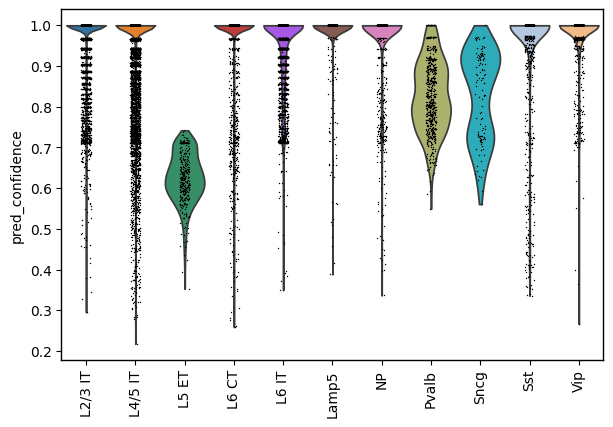

In [22]:
sc.pl.violin(adata_ga, keys="pred_confidence", groupby="pred_cell_type", rotation=90)

In [23]:
# sc.pp.neighbors(adata, use_rep="X_supbiot", n_neighbors=50, metric="cosine")
# sc.tl.umap(adata, min_dist=0.3, spread=1.0, random_state=0)
# sc.pl.umap(adata, color='modality')

In [24]:
sc.pp.neighbors(adata, use_rep="X_supbiot", n_neighbors=50, metric="cosine")
sc.tl.umap(adata, min_dist=0.3, spread=1.0, random_state=0)

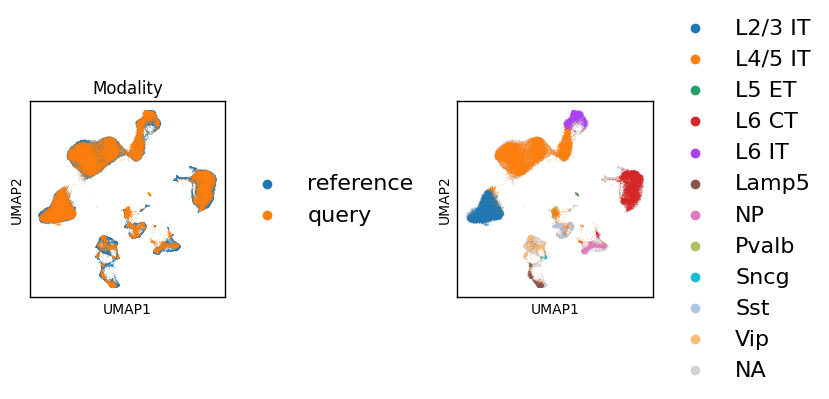

In [25]:
sc.settings._vector_friendly = True

# Make sure the default edge isn’t white or hairline
mpl.rcParams['axes.edgecolor'] = 'black'
mpl.rcParams['axes.linewidth'] = 1.0

def force_border(ax):
    ax.set_axis_on()           # ensure axes are on
    ax.set_frame_on(True)      # ensure frame is drawn
    ax.patch.set_visible(True) # ensure background patch exists
    for side in ax.spines.values():
        side.set_visible(True)
        side.set_color('black')
        side.set_linewidth(1.0)

methods = ["X_supbiot"]

ncols = 2 * len(methods)
fig, axes = plt.subplots(1, ncols, figsize=(4.2*ncols, 4.2), squeeze=False)
axes = axes[0]

for i, method in enumerate(methods):    
    axL, axR = axes[2*i], axes[2*i+1]   

    sc.pl.embedding(
        adata, basis="umap", color="modality",
        frameon=True, ax=axL, show=False,
        legend_loc="right margin", legend_fontsize=16, title='Modality'
    )
    axL.set_box_aspect(1)
    axL.set_xlabel("UMAP1"); axL.set_ylabel("UMAP2")
    force_border(axL)    

    sc.pl.embedding(
        adata, basis="umap", color="pred_cell_type",
        frameon=True, ax=axR, show=False,
        legend_loc="right margin", legend_fontsize=16, title=""
    )
    axR.set_box_aspect(1)
    axR.set_xlabel("UMAP1"); axR.set_ylabel("UMAP2")
    force_border(axR)
   

plt.tight_layout()
# fig.savefig(f"{cwd}_batch_and_leiden_per_embedding.pdf", dpi=300, transparent=True)


In [26]:
adata_ga

AnnData object with n_obs × n_vars = 54844 × 15185
    obs: 'domain', 'protocol', 'dataset', 'cell_type', 'modality', 'obs_original', 'pred_cell_type', 'pred_confidence'
    uns: '_ot_alignment', '_supbiot', 'neighbors', 'umap', 'modality_colors', 'pred_cell_type_colors'
    obsm: 'X_shared_pca', 'X_supbiot', 'X_umap'
    obsp: 'distances', 'connectivities'

In [27]:
# Map true labels back
adata_ga.obs['cell_type'] = adata_atac.obs['cell_type']

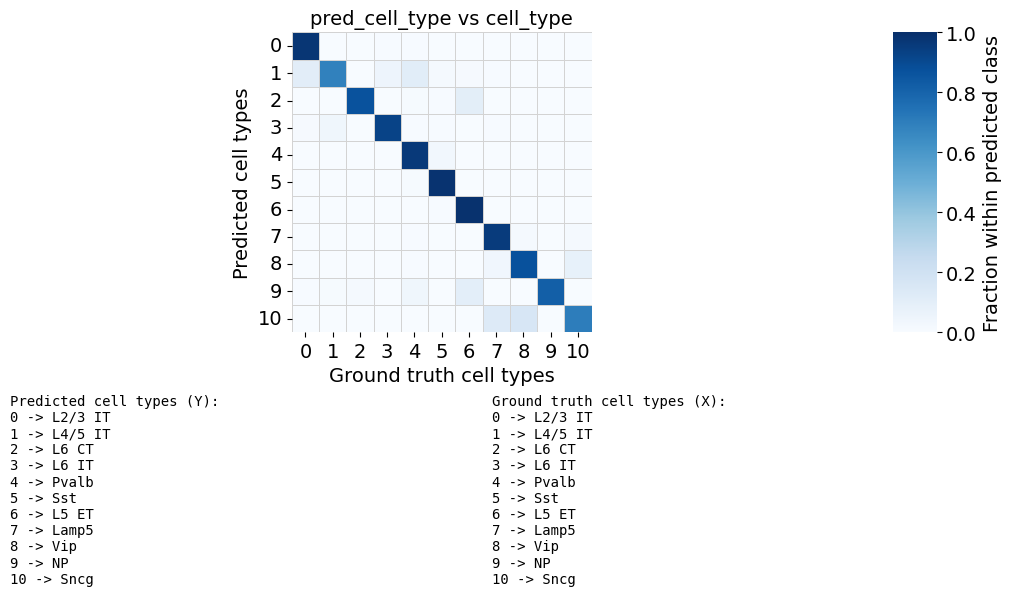

In [28]:
fig, ax, counts_df, norm_df = scb.pl.plot_anndata_confusion(
    adata_ga,
    true_key="cell_type",
    pred_key="pred_cell_type",
    drop_unknown=False,          # key line
    normalize="pred",
    annotate_mapping=True,
    return_data=True,
)

In [29]:
from sklearn.metrics import normalized_mutual_info_score

y_true = adata_ga.obs["cell_type"].astype(str)
y_pred = adata_ga.obs["pred_cell_type"].astype(str)

# keep only valid rows
mask = y_true.notna() & y_pred.notna()

# (optional) ignore "unknown" labels
# mask &= (y_true != "unknown") & (y_pred != "unknown")

nmi = normalized_mutual_info_score(
    y_true[mask].to_numpy(),
    y_pred[mask].to_numpy(),
    average_method="arithmetic",
)

print(f"NMI = {nmi:.6f}")

NMI = 0.721083
